# DermAugment - Skin Lesion Augmentation Pipeline with GAN

## Section 1: Mount Google Drive & Install Dependencies

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install required packages
!pip install -q albumentations opencv-python-headless Pillow tqdm matplotlib seaborn

In [3]:
# Imports
import os
import re
import shutil
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
from PIL import Image, ImageEnhance
from tqdm.notebook import tqdm
from collections import defaultdict
from copy import deepcopy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.utils as vutils

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## Section 2: Configuration & Global Constants

In [4]:
# Paths
IMG_DIR      = '/content/drive/MyDrive/ISIC2018_Task3_Training/images'
CSV_PATH     = '/content/drive/MyDrive/ISIC2018_Task3_Training/ISIC2018_Task3_Training_GroundTruth.csv'
FINAL_DIR    = '/content/final_dataset'
GAN_CKPT_DIR = '/content/gan_checkpoints'

os.makedirs(FINAL_DIR, exist_ok=True)
os.makedirs(GAN_CKPT_DIR, exist_ok=True)

# Dataset parameters
CLASSES          = ['NV', 'MEL', 'BKL', 'BCC', 'AKIEC', 'VASC', 'DF']
TARGET_PER_CLASS = 1000
IMG_SIZE         = 128

# GAN budget
GAN_PER_CLASS = 100

# GAN hyper-parameters
LATENT_DIM   = 100
N_EPOCHS_GAN = 100
BATCH_GAN    = 32
LR_GAN       = 2e-4
BETA1_GAN    = 0.5
NGF = NCF    = 64


## Section 3: Data Loading & Label Mapping

In [5]:
# Load CSV
df_raw = pd.read_csv(CSV_PATH)
print(f'CSV shape: {df_raw.shape}')
df_raw.head(5)

CSV shape: (10015, 8)


,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC
0,ISIC_0024306,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0024307,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0024308,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0024309,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0024310,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
# Map one-hot labels → class name
def map_label(row, classes):
    """Return the class name for a one-hot encoded row."""
    for cls in classes:
        if cls in row.index and row[cls] == 1.0:
            return cls
    return None

df_raw['label'] = df_raw.apply(lambda r: map_label(r, CLASSES), axis=1)

# Build image path
df_raw['image_path'] = df_raw['image'].apply(
    lambda x: os.path.join(IMG_DIR, f"{x}.jpg")
)

# Keep only records whose file actually exists
df_raw = df_raw[df_raw['image_path'].apply(os.path.exists)].copy()
df_raw = df_raw[df_raw['label'].notna()].copy()
df_raw.reset_index(drop=True, inplace=True)

# Final DataFrame
df = df_raw[['image_path', 'label']].copy()
print(f'DataFrame ready — {len(df)} valid records')
print(df['label'].value_counts())

DataFrame ready — 10015 valid records
label
NV       6705
MEL      1113
BKL      1099
BCC       514
AKIEC     327
VASC      142
DF        115
Name: count, dtype: int64


## Section 4: Preprocessing Utilities

In [7]:
# 4.1 Shades-of-Gray colour normalisation
def shades_of_gray(img_bgr: np.ndarray, power: float = 6.0) -> np.ndarray:
    """
    Shades-of-Gray colour constancy.
    img_bgr: uint8 BGR image (H×W×3)
    Returns: uint8 BGR image
    """
    img = img_bgr.astype(np.float32)
    illuminant = np.power(
        np.mean(np.power(img + 1e-6, power), axis=(0, 1)),
        1.0 / power
    )
    scale = (illuminant / (np.mean(illuminant) + 1e-6))
    img_norm = np.clip(img / (scale + 1e-6), 0, 255).astype(np.uint8)
    return img_norm


# 4.2 Hair removal (DullRazor algorithm)
def remove_hair(img_bgr: np.ndarray) -> np.ndarray:
    """
    DullRazor-style hair removal using morphological black-hat + inpainting.
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    # Black-hat to detect dark hair strands
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    # Threshold hair mask
    _, hair_mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    # Inpaint to remove hair
    result = cv2.inpaint(img_bgr, hair_mask, inpaintRadius=3,
                         flags=cv2.INPAINT_TELEA)
    return result


# 4.3 Full preprocessing pipeline
def preprocess_image(path: str, size: int = IMG_SIZE) -> np.ndarray | None:
    """
    Load → hair removal → Shades-of-Gray → resize → return uint8 RGB numpy.
    Returns None on any error.
    """
    try:
        img = cv2.imread(path)
        if img is None:
            return None
        img = remove_hair(img)
        img = shades_of_gray(img)
        img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return img
    except Exception:
        return None


print('Preprocessing functions defined.')

Preprocessing functions defined.


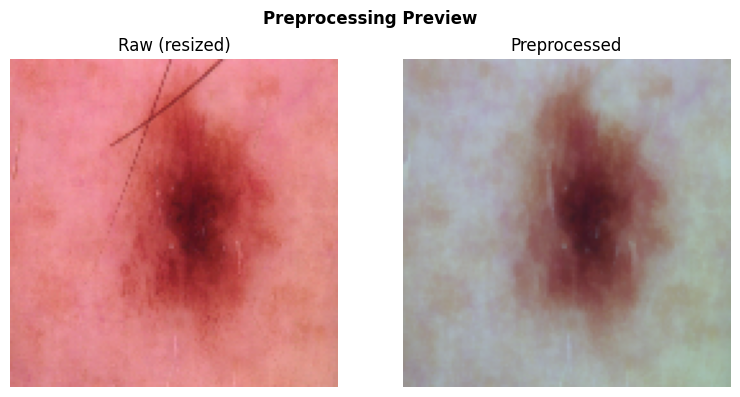

In [8]:
# 4.4 Quick sanity check — show raw vs preprocessed
sample_path = df.iloc[0]['image_path']
raw_img  = cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB)
proc_img = preprocess_image(sample_path)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(cv2.resize(raw_img, (IMG_SIZE, IMG_SIZE))); axes[0].set_title('Raw (resized)')
axes[1].imshow(proc_img);                                   axes[1].set_title('Preprocessed')
for ax in axes: ax.axis('off')
plt.suptitle('Preprocessing Preview', fontweight='bold')
plt.tight_layout()
plt.show()

## Section 5: Exploratory Data Analysis

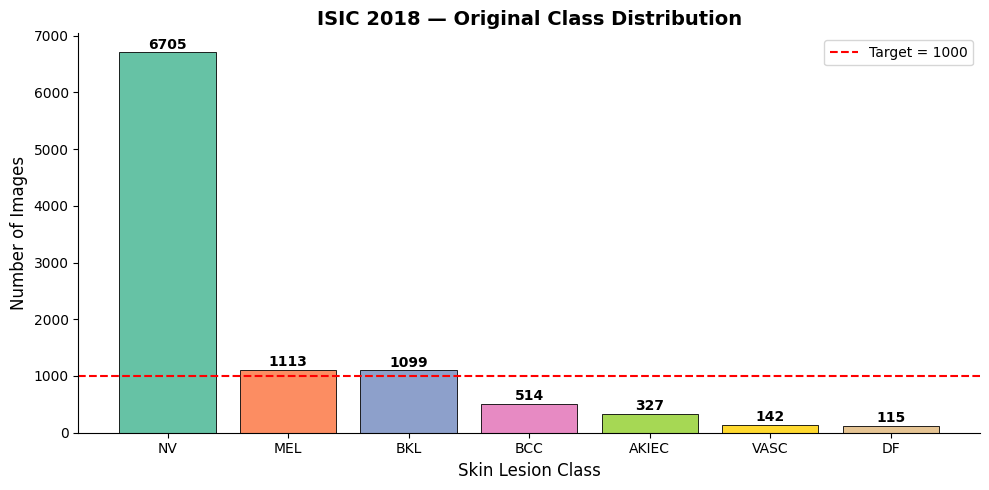

Class counts:
  NV    :  6705  →  need    0 more
  MEL   :  1113  →  need    0 more
  BKL   :  1099  →  need    0 more
  BCC   :   514  →  need  486 more
  AKIEC :   327  →  need  673 more
  VASC  :   142  →  need  858 more
  DF    :   115  →  need  885 more


In [9]:
# 5.1 Class distribution bar chart
class_counts = df['label'].value_counts().reindex(CLASSES)

palette = sns.color_palette('Set2', len(CLASSES))
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(class_counts.index, class_counts.values, color=palette, edgecolor='black', linewidth=0.6)
ax.axhline(TARGET_PER_CLASS, color='red', linestyle='--', linewidth=1.5, label=f'Target = {TARGET_PER_CLASS}')
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xlabel('Skin Lesion Class', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('ISIC 2018 — Original Class Distribution', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

print('Class counts:')
for cls, cnt in class_counts.items():
    need = max(0, TARGET_PER_CLASS - cnt)
    print(f'  {cls:6s}: {cnt:5d}  →  need {need:4d} more')

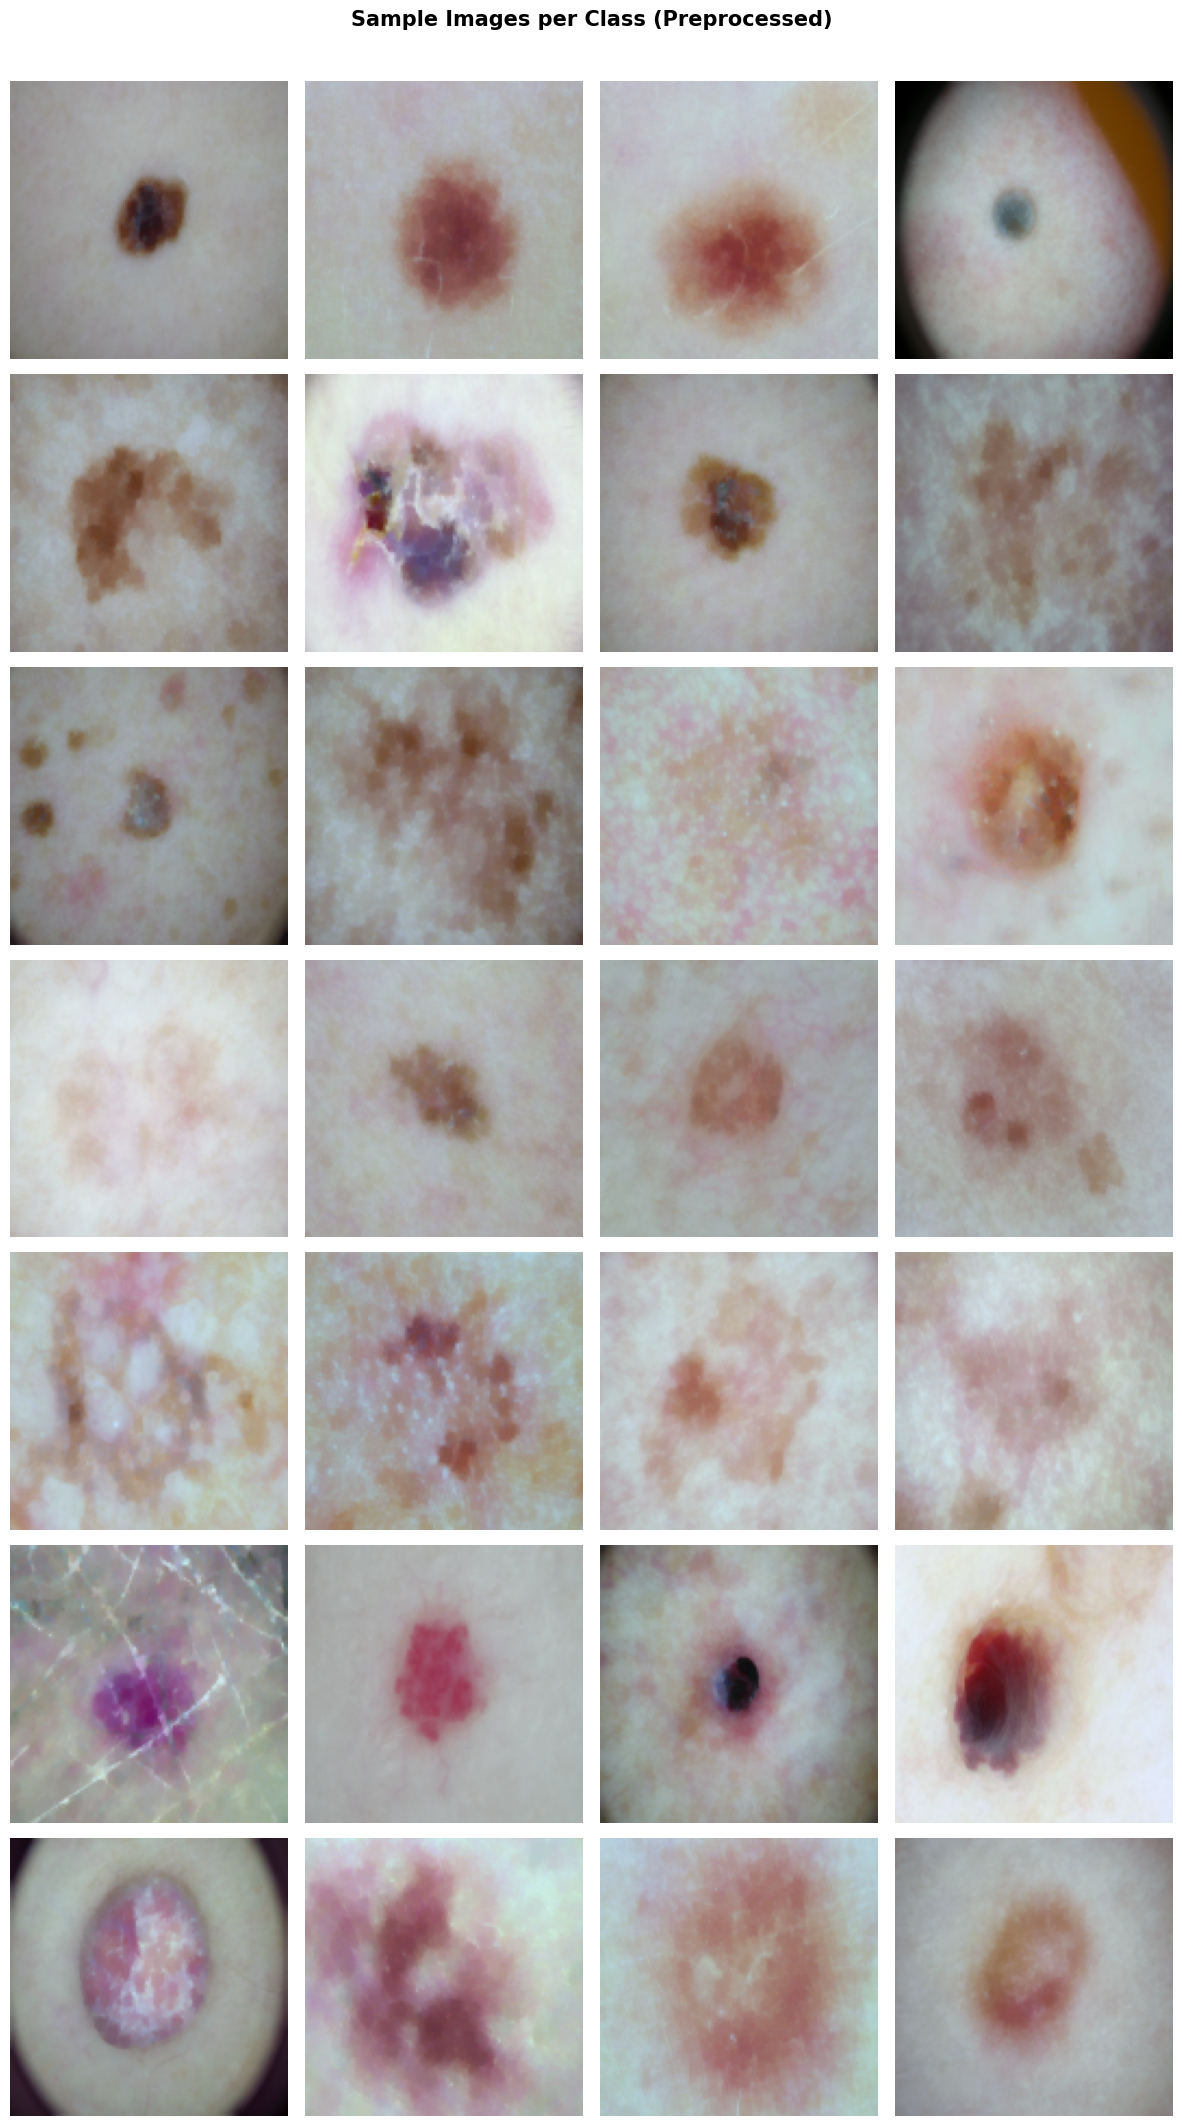

In [10]:
# 5.2 Sample images per class
N_SAMPLES = 4
fig, axes = plt.subplots(len(CLASSES), N_SAMPLES, figsize=(N_SAMPLES * 3, len(CLASSES) * 3))

for row_idx, cls in enumerate(CLASSES):
    cls_paths = df[df['label'] == cls]['image_path'].tolist()
    samples   = random.sample(cls_paths, min(N_SAMPLES, len(cls_paths)))
    for col_idx in range(N_SAMPLES):
        ax = axes[row_idx][col_idx]
        if col_idx < len(samples):
            img = preprocess_image(samples[col_idx])
            if img is not None:
                ax.imshow(img)
        ax.axis('off')
        if col_idx == 0:
            ax.set_ylabel(cls, fontsize=12, fontweight='bold', rotation=0,
                          labelpad=40, va='center')

plt.suptitle('Sample Images per Class (Preprocessed)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Section 6: DermAugment Module

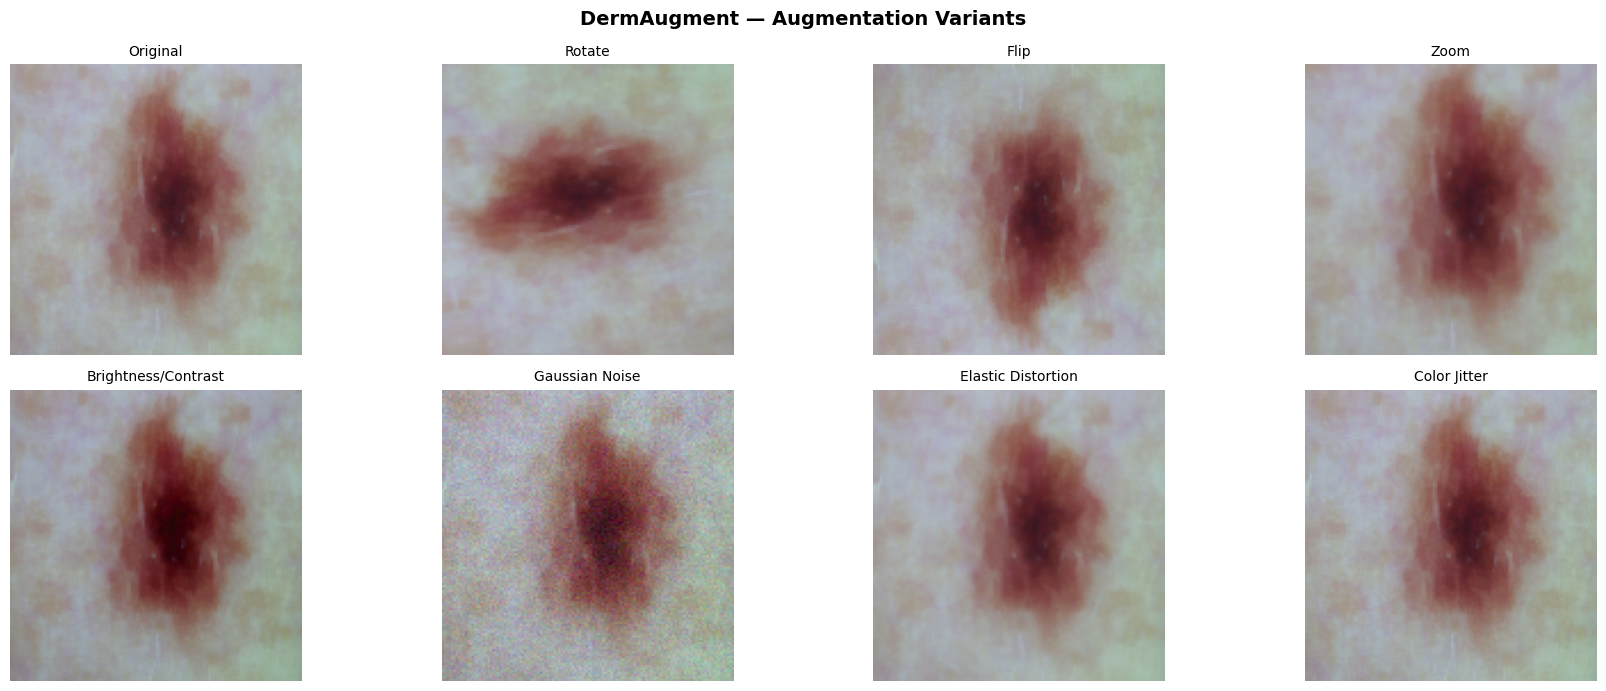

DermAugment module ready.


In [11]:
class DermAugment:
    """
    Custom dermoscopy-specific augmentation class.
    All augmentations are label-preserving (no class-altering transforms).
    Input/Output: numpy uint8 RGB (H×W×3).
    """

    def __init__(self, seed: int = SEED):
        self.rng = np.random.default_rng(seed)

    # Classical augmentations

    def rotate(self, img: np.ndarray, angle: float | None = None) -> np.ndarray:
        """Rotate by a random angle in [-180, 180]."""
        if angle is None:
            angle = self.rng.uniform(-180, 180)
        h, w = img.shape[:2]
        M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
        return cv2.warpAffine(img, M, (w, h),
                              flags=cv2.INTER_LINEAR,
                              borderMode=cv2.BORDER_REFLECT_101)

    def flip(self, img: np.ndarray, mode: int | None = None) -> np.ndarray:
        """Horizontal (1), vertical (0), or both (-1) flip."""
        if mode is None:
            mode = int(self.rng.integers(-1, 2))
        return cv2.flip(img, mode)

    def zoom(self, img: np.ndarray, factor: float | None = None) -> np.ndarray:
        """Centre-crop zoom in range [0.8, 1.2]."""
        if factor is None:
            factor = self.rng.uniform(0.80, 1.20)
        h, w = img.shape[:2]
        new_h, new_w = int(h * factor), int(w * factor)
        resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
        if factor >= 1.0:                        # crop centre back to original
            y1 = (new_h - h) // 2
            x1 = (new_w - w) // 2
            out = resized[y1:y1+h, x1:x1+w]
        else:                                    # pad with reflection
            pad_y = (h - new_h) // 2
            pad_x = (w - new_w) // 2
            out = cv2.copyMakeBorder(resized, pad_y, h - new_h - pad_y,
                                     pad_x, w - new_w - pad_x,
                                     cv2.BORDER_REFLECT_101)
        return cv2.resize(out, (w, h))

    def brightness_contrast(self, img: np.ndarray,
                            alpha: float | None = None,
                            beta: float | None = None) -> np.ndarray:
        """Adjust brightness (beta ∈ [-40,40]) and contrast (alpha ∈ [0.7,1.3])."""
        if alpha is None:
            alpha = self.rng.uniform(0.70, 1.30)
        if beta is None:
            beta = self.rng.uniform(-40, 40)
        out = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)
        return out

    # Advanced augmentations

    def gaussian_noise(self, img: np.ndarray, sigma: float = 10.0) -> np.ndarray:
        """Add Gaussian noise."""
        noise = self.rng.normal(0, sigma, img.shape).astype(np.int16)
        return np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    def elastic_distortion(self, img: np.ndarray,
                           alpha: float = 20.0, sigma: float = 4.0) -> np.ndarray:
        """Elastic deformation — mimics skin surface variation."""
        h, w = img.shape[:2]
        dx = cv2.GaussianBlur(
            (self.rng.random((h, w)) * 2 - 1).astype(np.float32), (0, 0), sigma
        ) * alpha
        dy = cv2.GaussianBlur(
            (self.rng.random((h, w)) * 2 - 1).astype(np.float32), (0, 0), sigma
        ) * alpha
        x, y = np.meshgrid(np.arange(w), np.arange(h))
        map_x = np.clip(x + dx, 0, w - 1).astype(np.float32)
        map_y = np.clip(y + dy, 0, h - 1).astype(np.float32)
        return cv2.remap(img, map_x, map_y, cv2.INTER_LINEAR,
                         borderMode=cv2.BORDER_REFLECT_101)

    def color_jitter(self, img: np.ndarray) -> np.ndarray:
        """Per-channel colour jitter."""
        pil_img = Image.fromarray(img)
        pil_img = ImageEnhance.Color(pil_img).enhance(self.rng.uniform(0.8, 1.2))
        pil_img = ImageEnhance.Sharpness(pil_img).enhance(self.rng.uniform(0.8, 1.5))
        return np.array(pil_img)

    # Compose a random augmentation

    def random_augment(self, img: np.ndarray) -> np.ndarray:
        """
        Apply a random combination of augmentations.
        Each transform applied independently with p=0.5.
        """
        transforms_pool = [
            self.rotate,
            self.flip,
            self.zoom,
            self.brightness_contrast,
            self.gaussian_noise,
            self.elastic_distortion,
            self.color_jitter,
        ]
        out = img.copy()
        for transform in transforms_pool:
            if self.rng.random() > 0.5:
                out = transform(out)
        return out


# Quick visual test
augmentor = DermAugment()
test_img  = preprocess_image(df.iloc[0]['image_path'])

aug_variants = {
    'Original'          : test_img,
    'Rotate'            : augmentor.rotate(test_img),
    'Flip'              : augmentor.flip(test_img),
    'Zoom'              : augmentor.zoom(test_img),
    'Brightness/Contrast': augmentor.brightness_contrast(test_img),
    'Gaussian Noise'    : augmentor.gaussian_noise(test_img),
    'Elastic Distortion': augmentor.elastic_distortion(test_img),
    'Color Jitter'      : augmentor.color_jitter(test_img),
}

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, (title, img_v) in zip(axes.flatten(), aug_variants.items()):
    ax.imshow(img_v); ax.set_title(title, fontsize=10); ax.axis('off')
plt.suptitle('DermAugment — Augmentation Variants', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('DermAugment module ready.')

## Section 7: DCGAN Module

In [12]:
# 7.1 Weight initialisation
def weights_init(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


# 7.2 Generator
class Generator(nn.Module):
    """
    DCGAN Generator: latent z (100) → RGB 128×128.
    Architecture: 5 transposed-conv blocks + final tanh.
    """
    def __init__(self, latent_dim: int = LATENT_DIM, ngf: int = NGF):
        super().__init__()
        self.net = nn.Sequential(
            # z (1×1) → 4×4
            nn.ConvTranspose2d(latent_dim, ngf * 16, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 16), nn.ReLU(True),
            # 4→8
            nn.ConvTranspose2d(ngf * 16, ngf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 8),  nn.ReLU(True),
            # 8→16
            nn.ConvTranspose2d(ngf * 8, ngf * 4,  4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),  nn.ReLU(True),
            # 16→32
            nn.ConvTranspose2d(ngf * 4, ngf * 2,  4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),  nn.ReLU(True),
            # 32→64
            nn.ConvTranspose2d(ngf * 2, ngf,       4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),       nn.ReLU(True),
            # 64→128
            nn.ConvTranspose2d(ngf,    3,           4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)


# 7.3 Discriminator
class Discriminator(nn.Module):
    """
    DCGAN Discriminator: RGB 128×128 → real/fake scalar per image.
    Uses Spectral Norm for training stability.
    AdaptiveAvgPool2d(1) collapses any spatial remainder to 1×1
    so output is always shape [batch] regardless of input size.
    """
    def __init__(self, ncf: int = NCF):
        super().__init__()
        def conv_block(in_c, out_c, bn=True):
            layers = [nn.utils.spectral_norm(
                nn.Conv2d(in_c, out_c, 4, 2, 1, bias=False)
            )]
            if bn:
                layers += [nn.BatchNorm2d(out_c)]
            layers += [nn.LeakyReLU(0.2, inplace=True)]
            return layers

        self.net = nn.Sequential(
            *conv_block(3,       ncf,     bn=False),  # 128→64
            *conv_block(ncf,     ncf*2),              # 64→32
            *conv_block(ncf*2,   ncf*4),              # 32→16
            *conv_block(ncf*4,   ncf*8),              # 16→8
            nn.Conv2d(ncf*8, 1, 4, 1, 0, bias=False), # 8→5 (spatial)
            nn.AdaptiveAvgPool2d(1),                   # 5→1 (force scalar)
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).view(-1)   # [batch, 1, 1, 1] → [batch]


# Print summary — D output must be [batch]
G_test = Generator().to(DEVICE)
D_test = Discriminator().to(DEVICE)
z_test = torch.randn(4, LATENT_DIM, 1, 1).to(DEVICE)
out_G  = G_test(z_test)
out_D  = D_test(out_G)
assert out_D.shape == torch.Size([4]), f'D shape error: {out_D.shape}'
print(f'   Generator output shape     : {out_G.shape}')   # [4, 3, 128, 128]
print(f'   Discriminator output shape : {out_D.shape}')   # [4]
del G_test, D_test, z_test, out_G, out_D

   Generator output shape     : torch.Size([4, 3, 128, 128])
   Discriminator output shape : torch.Size([4])


In [13]:
# 7.4 Per-class dataset for GAN training
class SkinLesionDataset(Dataset):
    """Loads preprocessed images for a single class for GAN training."""

    def __init__(self, paths: list[str], size: int = IMG_SIZE):
        self.paths = paths
        self.transform = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3),   # → [-1, 1]
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = preprocess_image(self.paths[idx])
        if img is None:
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        pil = Image.fromarray(img)
        return self.transform(pil)

In [14]:
# 7.5 GAN training function
def train_dcgan(class_name: str,
                img_paths: list[str],
                n_epochs: int = N_EPOCHS_GAN,
                batch_size: int = BATCH_GAN) -> Generator:
    """
    Train a DCGAN on images from `class_name`.
    Returns the trained Generator.
    Saves generator checkpoint to GAN_CKPT_DIR.
    """
    ckpt_path = os.path.join(GAN_CKPT_DIR, f'G_{class_name}.pth')

    # Load checkpoint if it already exists
    G = Generator(LATENT_DIM, NGF).to(DEVICE)
    G.apply(weights_init)

    if os.path.exists(ckpt_path):
        G.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        print(f'Loaded cached GAN for {class_name}')
        return G

    # Setup
    D = Discriminator(NCF).to(DEVICE)
    D.apply(weights_init)

    criterion  = nn.BCELoss()
    optG = optim.Adam(G.parameters(), lr=LR_GAN, betas=(BETA1_GAN, 0.999))
    optD = optim.Adam(D.parameters(), lr=LR_GAN, betas=(BETA1_GAN, 0.999))

    dataset    = SkinLesionDataset(img_paths)
    dataloader = DataLoader(dataset, batch_size=batch_size,
                            shuffle=True, num_workers=2, pin_memory=True,
                            drop_last=True)

    real_label, fake_label = 0.9, 0.1   # label smoothing

    print(f'Training GAN for class [{class_name}]  '
          f'— {len(img_paths)} images, {n_epochs} epochs')

    loss_G_hist, loss_D_hist = [], []

    for epoch in range(1, n_epochs + 1):
        epoch_lossG, epoch_lossD = 0.0, 0.0

        for real_imgs in dataloader:
            real_imgs = real_imgs.to(DEVICE)
            bs        = real_imgs.size(0)

            # Train Discriminator
            D.zero_grad()
            label_r = torch.full((bs,), real_label, device=DEVICE)
            label_f = torch.full((bs,), fake_label, device=DEVICE)

            out_real  = D(real_imgs)
            loss_D_r  = criterion(out_real, label_r)

            z         = torch.randn(bs, LATENT_DIM, 1, 1, device=DEVICE)
            fake_imgs = G(z).detach()
            out_fake  = D(fake_imgs)
            loss_D_f  = criterion(out_fake, label_f)

            loss_D = loss_D_r + loss_D_f
            loss_D.backward()
            optD.step()

            # Train Generator
            G.zero_grad()
            z         = torch.randn(bs, LATENT_DIM, 1, 1, device=DEVICE)
            fake_imgs = G(z)
            out_fake  = D(fake_imgs)
            loss_G    = criterion(out_fake, label_r)   # fool D → real label
            loss_G.backward()
            optG.step()

            epoch_lossD += loss_D.item()
            epoch_lossG += loss_G.item()

        avg_lossD = epoch_lossD / len(dataloader)
        avg_lossG = epoch_lossG / len(dataloader)
        loss_D_hist.append(avg_lossD)
        loss_G_hist.append(avg_lossG)

        if epoch % 20 == 0 or epoch == 1:
            print(f'    Epoch [{epoch:3d}/{n_epochs}]  '
                  f'Loss_D: {avg_lossD:.4f}  Loss_G: {avg_lossG:.4f}')

    # Save checkpoint
    torch.save(G.state_dict(), ckpt_path)
    print(f'GAN training done for [{class_name}] — checkpoint saved.')

    # Plot loss curves
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(loss_D_hist, label='D Loss', color='coral')
    ax.plot(loss_G_hist, label='G Loss', color='steelblue')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.set_title(f'GAN Training Curve — {class_name}', fontweight='bold')
    ax.legend(); sns.despine()
    plt.tight_layout(); plt.show()

    return G

In [15]:
# 7.6 Image generation helper
def generate_gan_images(G: Generator,
                        n: int,
                        batch_size: int = 64) -> list[np.ndarray]:
    """
    Generate `n` synthetic images using trained Generator G.
    Returns a list of numpy uint8 RGB arrays (IMG_SIZE × IMG_SIZE × 3).
    """
    G.eval()
    images = []
    with torch.no_grad():
        for start in range(0, n, batch_size):
            bs = min(batch_size, n - start)
            z  = torch.randn(bs, LATENT_DIM, 1, 1, device=DEVICE)
            fake = G(z).cpu()                      # [-1, 1]
            fake = (fake * 0.5 + 0.5).clamp(0, 1) # [0, 1]
            for i in range(bs):
                arr = (fake[i].permute(1, 2, 0).numpy() * 255).astype(np.uint8)
                images.append(arr)
    G.train()
    return images

## Section 8: Dataset Balancing & Final Dataset Creation


In [16]:
# 8.1 Helper: save numpy array as image
def save_image(img_arr: np.ndarray, path: str):
    """Save uint8 RGB numpy array as JPEG."""
    Image.fromarray(img_arr).save(path, format='JPEG', quality=95)


# 8.2 Main balancing pipeline
def build_final_dataset(
    df:            pd.DataFrame,
    classes:       list,
    target:        int = TARGET_PER_CLASS,
    gan_per_class: int = GAN_PER_CLASS,
    final_dir:     str = FINAL_DIR,
    n_epochs_gan:  int = N_EPOCHS_GAN,
) -> dict:
    """
    Balanced dataset builder.
    Returns summary dict {class: {original, augmented, gan, total}}.
    """
    augmentor = DermAugment()
    summary   = {}

    for cls in classes:
        print(f'\n{"="*60}')
        print(f'  Processing class : {cls}')
        print(f'{"="*60}')

        cls_dir = os.path.join(final_dir, cls)
        os.makedirs(cls_dir, exist_ok=True)

        cls_paths = df[df['label'] == cls]['image_path'].tolist()
        n_orig    = len(cls_paths)
        print(f'  Available originals : {n_orig}')

        count_orig = count_aug = count_gan = 0

        # already have enough originals
        if n_orig >= target:
            print(f'  [RULE A] Sampling {target} originals — no aug, no GAN.')
            selected = random.sample(cls_paths, target)
            for idx, path in enumerate(tqdm(selected, desc=f'  [{cls}] copy originals')):
                img = preprocess_image(path)
                if img is None:
                    continue
                save_image(img, os.path.join(cls_dir, f'original_{idx:05d}.jpg'))
                count_orig += 1

        # need balancing
        else:
            aug_needed = target - n_orig - gan_per_class
            if aug_needed < 0:
                # Edge case: n_orig > target - gan_per_class
                # Use all originals + only GAN (no aug needed)
                aug_needed = 0
                actual_gan = target - n_orig
            else:
                actual_gan = gan_per_class

            print(f'  [RULE B] {n_orig} originals  +  '
                  f'{aug_needed} augmented  +  {actual_gan} GAN  =  {n_orig + aug_needed + actual_gan}')

            # copy all originals
            print(f'  Step 1: Copying all {n_orig} originals ...')
            for idx, path in enumerate(tqdm(cls_paths, desc=f'  [{cls}] originals')):
                img = preprocess_image(path)
                if img is None:
                    continue
                save_image(img, os.path.join(cls_dir, f'original_{idx:05d}.jpg'))
                count_orig += 1

            # augmented images
            if aug_needed > 0:
                print(f'  Step 2: Generating {aug_needed} augmented images ...')
                aug_idx = 0
                pbar    = tqdm(total=aug_needed, desc=f'  [{cls}] augmented')
                while count_aug < aug_needed:
                    img = preprocess_image(random.choice(cls_paths))
                    if img is None:
                        continue
                    out_path = os.path.join(cls_dir, f'aug_{aug_idx:06d}.jpg')
                    if not os.path.exists(out_path):
                        save_image(augmentor.random_augment(img), out_path)
                        count_aug += 1
                        pbar.update(1)
                    aug_idx += 1
                pbar.close()
            else:
                print(f'  Step 2: Skipped (no aug needed).')

            # GAN images (always for RULE B classes)
            print(f'  Step 3: Training GAN → generating {actual_gan} synthetic images ...')
            G        = train_dcgan(cls, cls_paths, n_epochs=n_epochs_gan)
            gan_imgs = generate_gan_images(G, actual_gan)
            for g_idx, g_img in enumerate(
                tqdm(gan_imgs, desc=f'  [{cls}] GAN images')
            ):
                out_path = os.path.join(cls_dir, f'gan_{g_idx:05d}.jpg')
                if not os.path.exists(out_path):
                    save_image(g_img, out_path)
                    count_gan += 1
            del G
            torch.cuda.empty_cache()

        # Verify
        actual = len(os.listdir(cls_dir))
        status = '✅' if actual == target else f'⚠️  expected {target}, got {actual}'
        print(f'  {status}  [{cls}] total = {actual}  '
              f'(orig={count_orig}, aug={count_aug}, gan={count_gan})')

        summary[cls] = {
            'original' : count_orig,
            'augmented': count_aug,
            'gan'      : count_gan,
            'total'    : actual,
        }

    return summary



  Processing class : NV
  Available originals : 6705
  [RULE A] Sampling 1000 originals — no aug, no GAN.


  [NV] copy originals:   0%|          | 0/1000 [00:00<?, ?it/s]

  ✅  [NV] total = 1000  (orig=1000, aug=0, gan=0)

  Processing class : MEL
  Available originals : 1113
  [RULE A] Sampling 1000 originals — no aug, no GAN.


  [MEL] copy originals:   0%|          | 0/1000 [00:00<?, ?it/s]

  ✅  [MEL] total = 1000  (orig=1000, aug=0, gan=0)

  Processing class : BKL
  Available originals : 1099
  [RULE A] Sampling 1000 originals — no aug, no GAN.


...

  ✅  [BKL] total = 1000  (orig=1000, aug=0, gan=0)

  Processing class : BCC
  Available originals : 514
  [RULE B] 514 originals  +  386 augmented  +  100 GAN  =  1000
  Step 1: Copying all 514 originals ...


  [BCC] originals:   0%|          | 0/514 [00:00<?, ?it/s]

  Step 2: Generating 386 augmented images ...


  [BCC] augmented:   0%|          | 0/386 [00:00<?, ?it/s]

  Step 3: Training GAN → generating 100 synthetic images ...
Training GAN for class [BCC]  — 514 images, 100 epochs
    Epoch [  1/100]  Loss_D: 1.1271  Loss_G: 4.3323
    Epoch [ 20/100]  Loss_D: 1.1213  Loss_G: 1.6807
    Epoch [ 40/100]  Loss_D: 1.1978  Loss_G: 1.5718
    Epoch [ 60/100]  Loss_D: 1.2715  Loss_G: 1.4717
    Epoch [ 80/100]  Loss_D: 1.2197  Loss_G: 1.3931
    Epoch [100/100]  Loss_D: 1.2210  Loss_G: 1.1763
GAN training done for [BCC] — checkpoint saved.


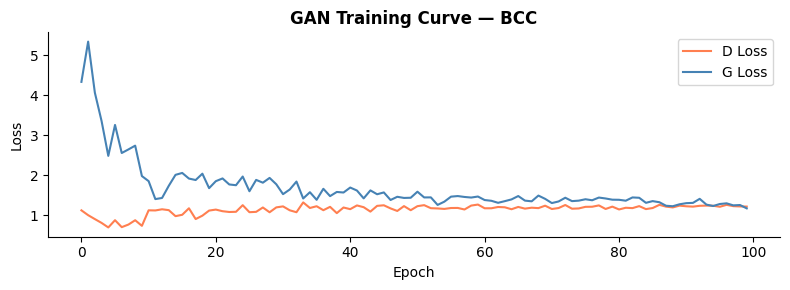

  [BCC] GAN images:   0%|          | 0/100 [00:00<?, ?it/s]

  ✅  [BCC] total = 1000  (orig=514, aug=386, gan=100)

  Processing class : AKIEC
  Available originals : 327
  [RULE B] 327 originals  +  573 augmented  +  100 GAN  =  1000
  Step 1: Copying all 327 originals ...


  [AKIEC] originals:   0%|          | 0/327 [00:00<?, ?it/s]

  Step 2: Generating 573 augmented images ...


  [AKIEC] augmented:   0%|          | 0/573 [00:00<?, ?it/s]

  Step 3: Training GAN → generating 100 synthetic images ...
Training GAN for class [AKIEC]  — 327 images, 100 epochs
    Epoch [  1/100]  Loss_D: 1.2025  Loss_G: 4.0580
    Epoch [ 20/100]  Loss_D: 0.6974  Loss_G: 2.6425
    Epoch [ 40/100]  Loss_D: 0.9975  Loss_G: 1.8792
    Epoch [ 60/100]  Loss_D: 1.1280  Loss_G: 1.5526
    Epoch [ 80/100]  Loss_D: 1.1363  Loss_G: 2.0199
    Epoch [100/100]  Loss_D: 1.1691  Loss_G: 1.4467
GAN training done for [AKIEC] — checkpoint saved.


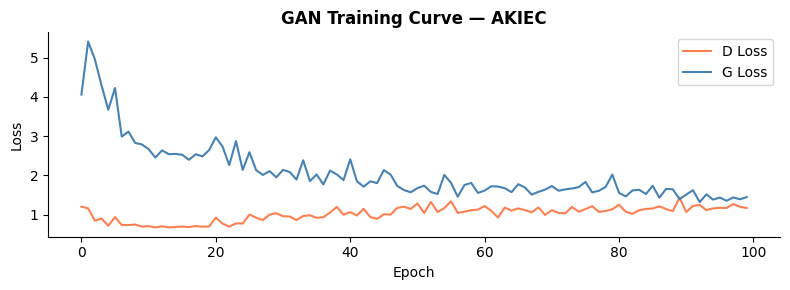

  [AKIEC] GAN images:   0%|          | 0/100 [00:00<?, ?it/s]

  ✅  [AKIEC] total = 1000  (orig=327, aug=573, gan=100)

  Processing class : VASC
  Available originals : 142
  [RULE B] 142 originals  +  758 augmented  +  100 GAN  =  1000
  Step 1: Copying all 142 originals ...


  [VASC] originals:   0%|          | 0/142 [00:00<?, ?it/s]

  Step 2: Generating 758 augmented images ...


  [VASC] augmented:   0%|          | 0/758 [00:00<?, ?it/s]

  Step 3: Training GAN → generating 100 synthetic images ...
Training GAN for class [VASC]  — 142 images, 100 epochs
    Epoch [  1/100]  Loss_D: 1.7291  Loss_G: 3.2049
    Epoch [ 20/100]  Loss_D: 0.6890  Loss_G: 3.0491
    Epoch [ 40/100]  Loss_D: 0.6561  Loss_G: 2.2778
    Epoch [ 60/100]  Loss_D: 0.6681  Loss_G: 2.1922
    Epoch [ 80/100]  Loss_D: 0.6655  Loss_G: 2.2254
    Epoch [100/100]  Loss_D: 0.6704  Loss_G: 2.4350
GAN training done for [VASC] — checkpoint saved.


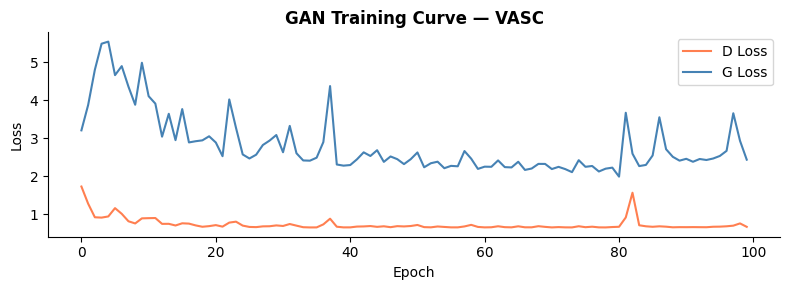

  [VASC] GAN images:   0%|          | 0/100 [00:00<?, ?it/s]

  ✅  [VASC] total = 1000  (orig=142, aug=758, gan=100)

  Processing class : DF
  Available originals : 115
  [RULE B] 115 originals  +  785 augmented  +  100 GAN  =  1000
  Step 1: Copying all 115 originals ...


  [DF] originals:   0%|          | 0/115 [00:00<?, ?it/s]

  Step 2: Generating 785 augmented images ...


  [DF] augmented:   0%|          | 0/785 [00:00<?, ?it/s]

  Step 3: Training GAN → generating 100 synthetic images ...
Training GAN for class [DF]  — 115 images, 100 epochs
    Epoch [  1/100]  Loss_D: 1.4224  Loss_G: 3.0379
    Epoch [ 20/100]  Loss_D: 0.8718  Loss_G: 4.9732
    Epoch [ 40/100]  Loss_D: 0.6757  Loss_G: 2.6945
    Epoch [ 60/100]  Loss_D: 0.7065  Loss_G: 3.1811
    Epoch [ 80/100]  Loss_D: 0.8206  Loss_G: 2.0612
    Epoch [100/100]  Loss_D: 1.0128  Loss_G: 1.9949
GAN training done for [DF] — checkpoint saved.


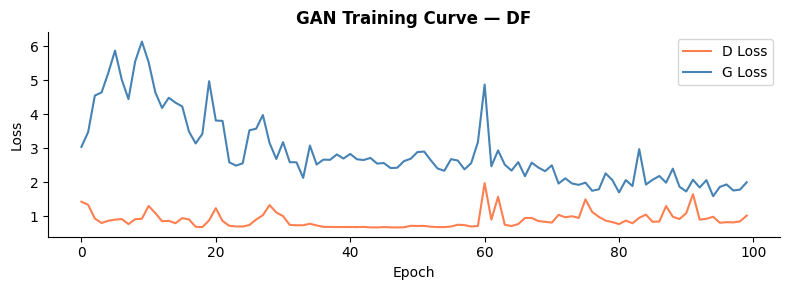

  [DF] GAN images:   0%|          | 0/100 [00:00<?, ?it/s]

  ✅  [DF] total = 1000  (orig=115, aug=785, gan=100)

  DATASET BALANCING COMPLETE
       original  augmented  gan  total
NV         1000          0    0   1000
MEL        1000          0    0   1000
BKL        1000          0    0   1000
BCC         514        386  100   1000
AKIEC       327        573  100   1000
VASC        142        758  100   1000
DF          115        785  100   1000


In [17]:
# 8.3 Run the full pipeline

summary = build_final_dataset(
    df=df,
    classes=CLASSES,
    target=TARGET_PER_CLASS,
    final_dir=FINAL_DIR,
    n_epochs_gan=N_EPOCHS_GAN,
)

print('\n' + '='*60)
print('  DATASET BALANCING COMPLETE')
print('='*60)
summary_df = pd.DataFrame(summary).T
print(summary_df.to_string())

## Section 9: Visualization of Final Dataset

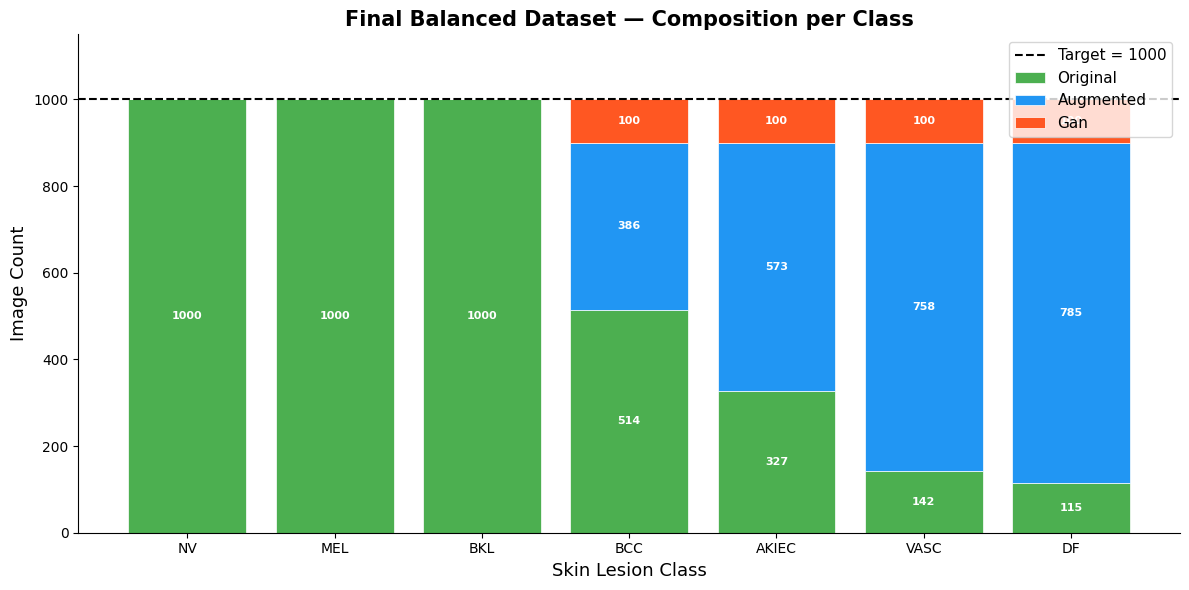

In [18]:
# 9.1 Final class distribution
summary_df = pd.DataFrame(summary).T.reindex(CLASSES)

fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(CLASSES))
colors = {'original': '#4CAF50', 'augmented': '#2196F3', 'gan': '#FF5722'}

for col, color in colors.items():
    vals = summary_df[col].values.astype(float)
    bars = ax.bar(CLASSES, vals, bottom=bottom, color=color, label=col.capitalize(),
                  edgecolor='white', linewidth=0.5)
    for bar, val, bot in zip(bars, vals, bottom):
        if val > 20:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bot + val/2, f'{int(val)}',
                    ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
    bottom += vals

ax.axhline(TARGET_PER_CLASS, color='black', linestyle='--',
           linewidth=1.5, label=f'Target = {TARGET_PER_CLASS}')
ax.set_ylim(0, TARGET_PER_CLASS * 1.15)
ax.set_xlabel('Skin Lesion Class', fontsize=13)
ax.set_ylabel('Image Count', fontsize=13)
ax.set_title('Final Balanced Dataset — Composition per Class',
             fontsize=15, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

In [21]:
# 9.2 Summary table with verification
summary_df['balanced'] = summary_df['total'].apply(
    lambda x: '✅OK' if int(x) == TARGET_PER_CLASS else f'⚠️  {int(x)}'
)
print('Final Dataset Summary (all classes should be exactly 1000):')
print(summary_df[['original','augmented','gan','total','balanced']].to_string())


Final Dataset Summary (all classes should be exactly 1000):
       original  augmented  gan  total balanced
NV         1000          0    0   1000      ✅OK
MEL        1000          0    0   1000      ✅OK
BKL        1000          0    0   1000      ✅OK
BCC         514        386  100   1000      ✅OK
AKIEC       327        573  100   1000      ✅OK
VASC        142        758  100   1000      ✅OK
DF          115        785  100   1000      ✅OK


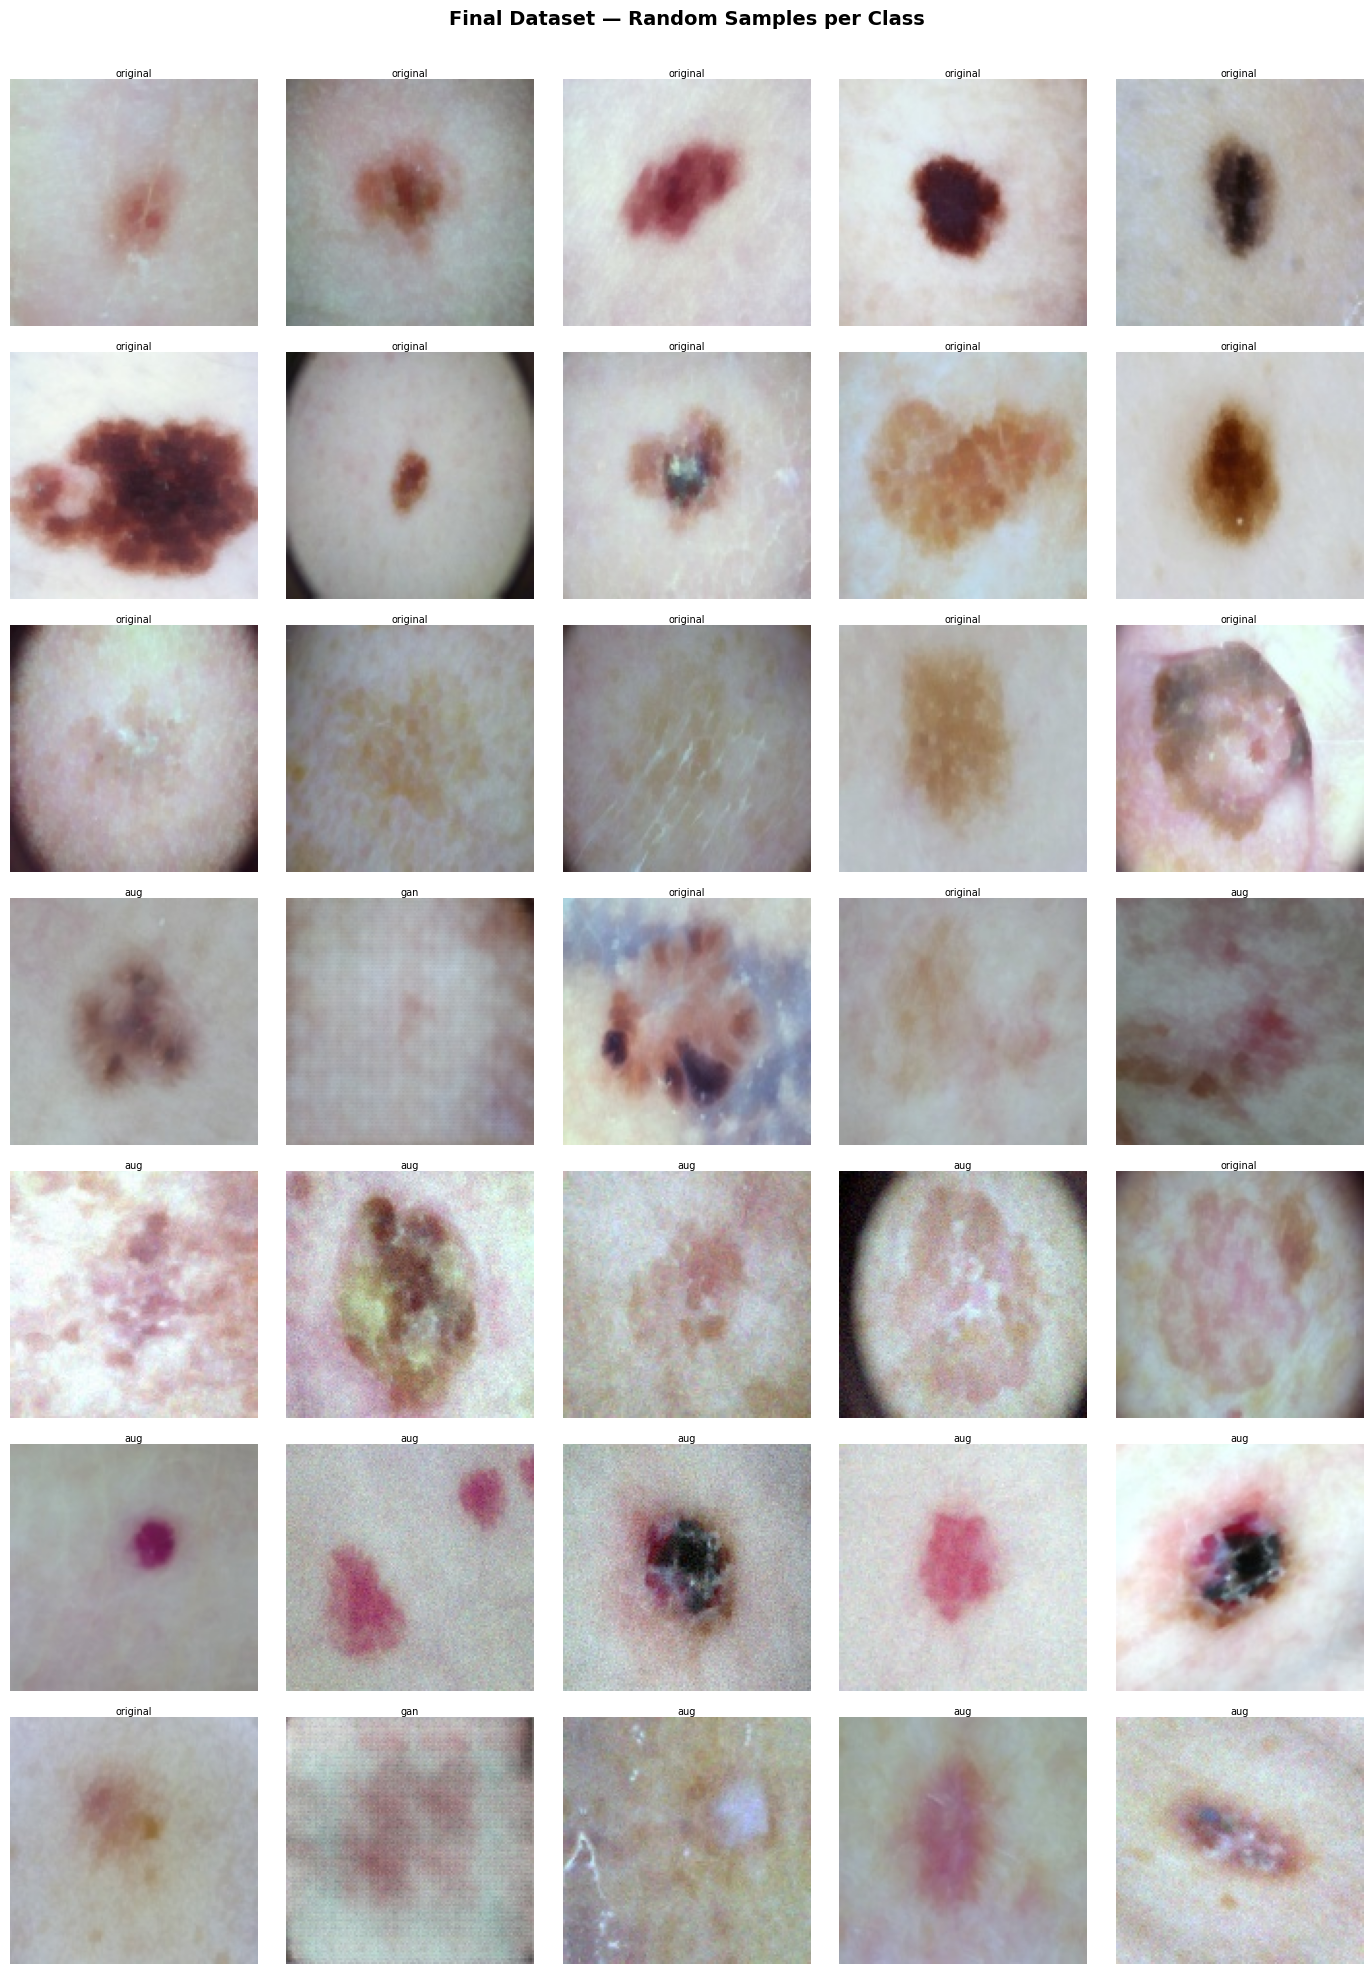

In [23]:
# 9.3 Random samples per class from final dataset
N_SHOW = 5
fig, axes = plt.subplots(len(CLASSES), N_SHOW,
                         figsize=(N_SHOW * 2.8, len(CLASSES) * 2.8))

for row_idx, cls in enumerate(CLASSES):
    cls_dir   = os.path.join(FINAL_DIR, cls)
    all_files = os.listdir(cls_dir)
    samples   = random.sample(all_files, min(N_SHOW, len(all_files)))
    for col_idx in range(N_SHOW):
        ax = axes[row_idx][col_idx]
        if col_idx < len(samples):
            img_path = os.path.join(cls_dir, samples[col_idx])
            img = np.array(Image.open(img_path))
            ax.imshow(img)
            prefix = samples[col_idx].split('_')[0]
            ax.set_title(prefix, fontsize=7, pad=2)
        ax.axis('off')
        if col_idx == 0:
            ax.set_ylabel(cls, fontsize=12, fontweight='bold',
                          rotation=0, labelpad=40, va='center')

plt.suptitle('Final Dataset — Random Samples per Class', fontsize=14,
             fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()

## Section 10: Save Final Dataset to Google Drive

In [26]:
# 10.1 Copy final dataset to Google Drive
DRIVE_OUTPUT = '/content/drive/MyDrive/DermAugFramework2/ISIC2018_Balanced_1000'
os.makedirs(DRIVE_OUTPUT, exist_ok=True)

print(f'Exporting final dataset to Google Drive ...')
print(f'Source : {FINAL_DIR}')
print(f'Dest   : {DRIVE_OUTPUT}')

for cls in tqdm(CLASSES, desc='Copying classes'):
    src = os.path.join(FINAL_DIR, cls)
    dst = os.path.join(DRIVE_OUTPUT, cls)
    if os.path.exists(dst):
        shutil.rmtree(dst)
    shutil.copytree(src, dst)

print('Export complete!')

# Verify counts on drive
print('Verification on Google Drive:')
for cls in CLASSES:
    cnt = len(os.listdir(os.path.join(DRIVE_OUTPUT, cls)))
    status = '✅' if cnt == TARGET_PER_CLASS else f'⚠️  got {cnt}'
    print(f'  {cls:6s} : {cnt}  {status}')

Exporting final dataset to Google Drive ...
Source : /content/final_dataset
Dest   : /content/drive/MyDrive/DermAugFramework2/ISIC2018_Balanced_1000


Copying classes:   0%|          | 0/7 [00:00<?, ?it/s]

Export complete!
Verification on Google Drive:
  NV     : 1000  ✅
  MEL    : 1000  ✅
  BKL    : 1000  ✅
  BCC    : 1000  ✅
  AKIEC  : 1000  ✅
  VASC   : 1000  ✅
  DF     : 1000  ✅


In [27]:
# 10.2 Save GAN checkpoints to Google Drive
DRIVE_CKPT = '/content/drive/MyDrive/DermAugFramework2/ISIC2018_GAN_Checkpoints'
os.makedirs(DRIVE_CKPT, exist_ok=True)

for ckpt_file in os.listdir(GAN_CKPT_DIR):
    shutil.copy(
        os.path.join(GAN_CKPT_DIR, ckpt_file),
        os.path.join(DRIVE_CKPT, ckpt_file)
    )
print('GAN checkpoints saved to Google Drive.')

GAN checkpoints saved to Google Drive.


In [28]:
# 10.3 Save summary CSV
SUMMARY_CSV = os.path.join(DRIVE_OUTPUT, 'dataset_summary.csv')
summary_df.to_csv(SUMMARY_CSV)
print(f'Summary CSV saved: {SUMMARY_CSV}')

Summary CSV saved: /content/drive/MyDrive/DermAugFramework2/ISIC2018_Balanced_1000/dataset_summary.csv


In [29]:
# 10.4 Build & save final metadata CSV with image paths + labels
records = []
for cls in CLASSES:
    cls_dir = os.path.join(DRIVE_OUTPUT, cls)
    for fname in sorted(os.listdir(cls_dir)):
        prefix = fname.split('_')[0]   # original / aug / gan
        records.append({
            'image_path' : os.path.join(cls_dir, fname),
            'label'      : cls,
            'source'     : prefix,
        })

metadata_df = pd.DataFrame(records)
META_CSV    = os.path.join(DRIVE_OUTPUT, 'final_metadata.csv')
metadata_df.to_csv(META_CSV, index=False)
print(f'Metadata CSV saved: {META_CSV}')
print(f'Total records : {len(metadata_df)}')
print(metadata_df['source'].value_counts())

Metadata CSV saved: /content/drive/MyDrive/DermAugFramework2/ISIC2018_Balanced_1000/final_metadata.csv
Total records : 7000
source
original    4098
aug         2502
gan          400
Name: count, dtype: int64


## Section 11: Final Verification & Pipeline Summary

In [31]:
# Final pipeline summary
print('DERMOSCOPIC AUGMENTATION PIPELINE — COMPLETE')
print(f'Target per class : {TARGET_PER_CLASS}')
print(f'GAN images / under-represented class : {GAN_PER_CLASS}')
print()
print(f'{"Class":8s} {"Rule":6s} {"Orig":6s} {"Aug":6s} {"GAN":5s} {"Total":6s} {"Status"}')
print('─' * 55)
all_ok = True
for cls, info in summary.items():
    rule   = 'A' if info['augmented'] == 0 and info['gan'] == 0 else 'B'
    ok     = int(info['total']) == TARGET_PER_CLASS
    status = '✅ OK' if ok else f'⚠️  {info["total"]}'
    if not ok: all_ok = False
    print(f'{cls:8s} {rule:6s} {info["original"]:6d} {info["augmented"]:6d} '
          f'{info["gan"]:5d} {info["total"]:6d}  {status}')
print('─' * 55)
total_imgs = sum(v['total'] for v in summary.values())
print(f'{"TOTAL":8s} {"":6s} '
      f'{sum(v["original"] for v in summary.values()):6d} '
      f'{sum(v["augmented"] for v in summary.values()):6d} '
      f'{sum(v["gan"] for v in summary.values()):5d} '
      f'{total_imgs:6d}')
print()
print('ALL CLASSES BALANCED' if all_ok else 'SOME CLASSES NEED REVIEW ⚠️')
print(f'Output directory: {DRIVE_OUTPUT}')


DERMOSCOPIC AUGMENTATION PIPELINE — COMPLETE
Target per class : 1000
GAN images / under-represented class : 100

Class    Rule   Orig   Aug    GAN   Total  Status
───────────────────────────────────────────────────────
NV       A        1000      0     0   1000  ✅ OK
MEL      A        1000      0     0   1000  ✅ OK
BKL      A        1000      0     0   1000  ✅ OK
BCC      B         514    386   100   1000  ✅ OK
AKIEC    B         327    573   100   1000  ✅ OK
VASC     B         142    758   100   1000  ✅ OK
DF       B         115    785   100   1000  ✅ OK
───────────────────────────────────────────────────────
TOTAL             4098   2502   400   7000

ALL CLASSES BALANCED
Output directory: /content/drive/MyDrive/DermAugFramework2/ISIC2018_Balanced_1000
